# 05 · C – Comparing & Kreuzvalidierung

Finale räumliche Güte, Baseline, Intervalle, Subgruppen und Erklärbarkeit.

**Projekt:** MietCheck · Data Analytics & Big Data

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

COLORS = {"navy": "#14213D", "blue": "#2563EB", "teal": "#0F766E",
          "amber": "#F59E0B", "red": "#DC2626", "grey": "#64748B"}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.titleweight": "bold",
                     "axes.labelsize": 10, "figure.dpi": 110})

def load_json(relative_path):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Projektwurzel: {ROOT}")

Projektwurzel: C:\Users\nelek\Desktop\Big Data\MietCheck


## Position der C-Phase

Die A³-Schleife hat gebaut und optimiert; C **entscheidet**. Es werden keine neuen Features und keine neuen Hyperparameter mehr gesucht. Die Phase beantwortet fünf Fragen:

1. Erfüllt das gewählte Modell die vorab definierten KPIs?
2. Wie groß ist der Vorteil gegenüber der fachlichen Baseline?
3. Wo irrt das Modell systematisch stärker?
4. Wie belastbar sind die Unsicherheitsintervalle auf neuen Regionen?
5. Ist HGB auch unter qualitativen Kriterien die richtige App-Entscheidung?

Damit bleibt der finale Test ein ehrlicher Nachweis und wird nicht zu einer weiteren Tuningrunde.

## Finale Evaluation

Das gewählte Modell wird auf 1.518.322 Entwicklungszeilen trainiert. 263.789 separate Zeilen kalibrieren Split-Conformal-Bänder. Erst danach werden 276.458 Zeilen aus 99 gesperrten Raumblöcken ausgewertet.

In [2]:
report = load_json("reports/final_model_evaluation.json")
test = report["test"]
comparison = pd.DataFrame([
    {"Modell": "Kategorien-Median", **test["category_median_baseline_metrics"]},
    {"Modell": "Finales HGB", **test["point_metrics"]},
])
display(comparison.round(3).style.hide(axis="index"))
print(f"MAE-Verbesserung zur Baseline: {test['mae_improvement_vs_baseline']:.1%}")

Modell,mae,median_ae,rmse,r2
Kategorien-Median,2.292000,1.560000,3.339000,-0.022000
Finales HGB,1.413000,0.956000,2.130000,0.584000


MAE-Verbesserung zur Baseline: 38.3%


### Formales KPI-Gate

Die vorab geforderte Verbesserung von mindestens 15 % wird mit 38,3 % deutlich erreicht. MAE 1,413 €/m² beschreibt den durchschnittlichen absoluten Fehler auf völlig neuen Raumblöcken; Median AE 0,956 €/m² zeigt, dass mindestens die Hälfte der Prognosen weniger als rund einen Euro pro Quadratmeter abweicht.

Intervall,calibrated_half_width_eur_sqm,coverage,mean_width_eur_sqm,mean_half_width_eur_sqm
global,2.731000,0.868000,5.461000,2.731000
kategoriespezifisch,nan,0.868000,5.463000,2.732000


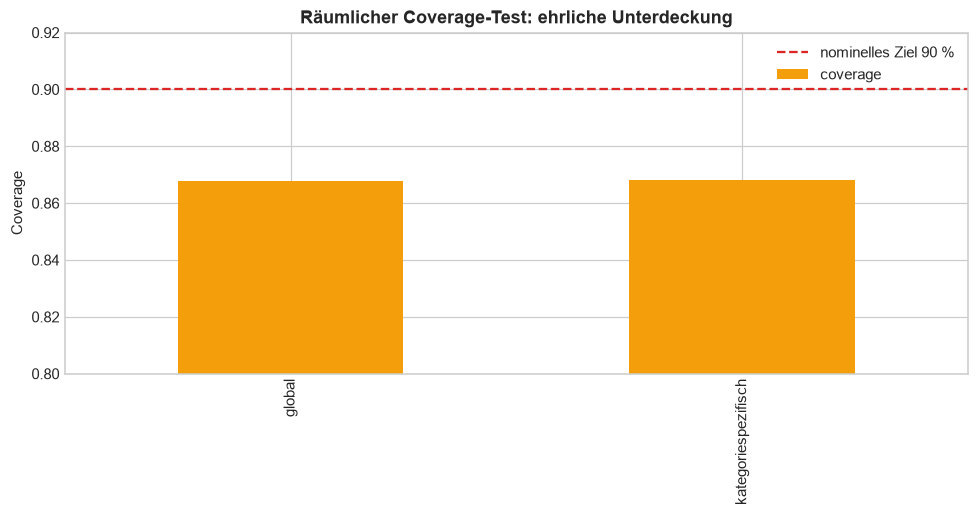

In [3]:
intervals = pd.DataFrame([
    {"Intervall": "global", **test["global_90_percent_interval"]},
    {"Intervall": "kategoriespezifisch",
     **{k: v for k, v in test["category_specific_90_percent_interval"].items()
        if k != "calibrated_half_widths_eur_sqm"}},
])
display(intervals.round(3).style.hide(axis="index"))

ax = intervals.plot.bar(x="Intervall", y="coverage", color=COLORS["amber"], legend=False)
ax.axhline(.90, color=COLORS["red"], linestyle="--", label="nominelles Ziel 90 %")
ax.set(ylim=(.80, .92), ylabel="Coverage", xlabel="",
       title="Räumlicher Coverage-Test: ehrliche Unterdeckung")
ax.legend(); plt.tight_layout(); plt.show()

### Warum die Coverage unter 90 % liegt

Split Conformal Prediction garantiert die nominelle Coverage nur unter Austauschbarkeit von Kalibrierungs- und Testbeobachtungen. Neue räumliche Regionen unterscheiden sich systematisch; deshalb erreicht das kategoriespezifische 90-%-Band empirisch 86,8 %. Wissenschaftlich korrekt ist nicht, die Zielzahl zu verstecken, sondern die **gemessene Testabdeckung** in App und Modellkarte auszuweisen.

Gruppe,Zeilen,MAE,R2,Coverage
official_target_certain,244888,1.414000,0.570000,0.868000
official_target_uncertain,31570,1.405000,0.181000,0.872000
category_0_0,81662,1.436000,0.547000,0.874000
category_0_1,114791,1.170000,0.603000,0.876000
category_1_0,29417,1.907000,0.487000,0.852000
category_1_1,50588,1.642000,0.550000,0.851000


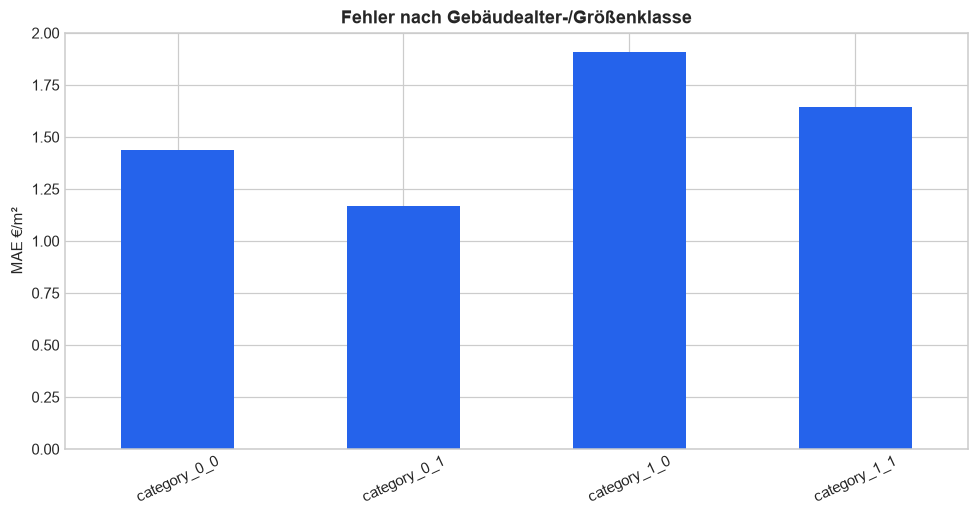

In [4]:
subgroups = []
for name, detail in test["subgroups"].items():
    subgroups.append({"Gruppe": name, "Zeilen": detail["rows"],
                      "MAE": detail["point_metrics"]["mae"],
                      "R2": detail["point_metrics"]["r2"],
                      "Coverage": detail["interval_metrics"]["coverage"]})
subgroups = pd.DataFrame(subgroups)
display(subgroups.round(3).style.hide(axis="index"))

category_groups = subgroups[subgroups["Gruppe"].str.startswith("category")]
ax = category_groups.plot.bar(x="Gruppe", y="MAE", color=COLORS["blue"], legend=False)
ax.set(title="Fehler nach Gebäudealter-/Größenklasse", ylabel="MAE €/m²", xlabel="")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

### Qualitative Bewertung

Die Professorenvorgabe verlangt neben Kennzahlen auch Interpretierbarkeit, Effizienz und Wartbarkeit. Die folgende Matrix ist eine transparente fachliche Bewertung auf einer Skala von 1 (schwach) bis 5 (stark); sie ersetzt keine Messwerte, sondern dokumentiert den Produktions-Trade-off.

In [5]:
decision = pd.DataFrame({
    "Kriterium": ["räumliche CV-Güte", "Test-/Produktionsnähe", "Interpretierbarkeit",
                  "Trainingsökonomie", "Wartbarkeit"],
    "Gewicht": [0.40, 0.20, 0.15, 0.10, 0.15],
    "HGB": [5, 5, 3, 4, 4],
    "Random Forest": [5, 4, 3, 2, 3],
    "Ridge": [3, 3, 5, 5, 5],
    "MLP": [3, 2, 2, 1, 2],
    "Kategorien-Median": [2, 2, 5, 5, 5],
})
scores = {
    model: float((decision[model] * decision["Gewicht"]).sum())
    for model in decision.columns[2:]
}
display(decision.style.format({"Gewicht": "{:.0%}"}).hide(axis="index"))
display(pd.Series(scores, name="gewichteter Score / 5").sort_values(ascending=False).to_frame())
print("Hinweis: Ordinales Entscheidungshilfsmittel; quantitative Messwerte bleiben separat.")

Kriterium,Gewicht,HGB,Random Forest,Ridge,MLP,Kategorien-Median
räumliche CV-Güte,40%,5,5,3,3,2
Test-/Produktionsnähe,20%,5,4,3,2,2
Interpretierbarkeit,15%,3,3,5,2,5
Trainingsökonomie,10%,4,2,5,1,5
Wartbarkeit,15%,4,3,5,2,5


,gewichteter Score / 5
HGB,4.45
Random Forest,3.90
Ridge,3.80
Kategorien-Median,3.20
MLP,2.30


Hinweis: Ordinales Entscheidungshilfsmittel; quantitative Messwerte bleiben separat.


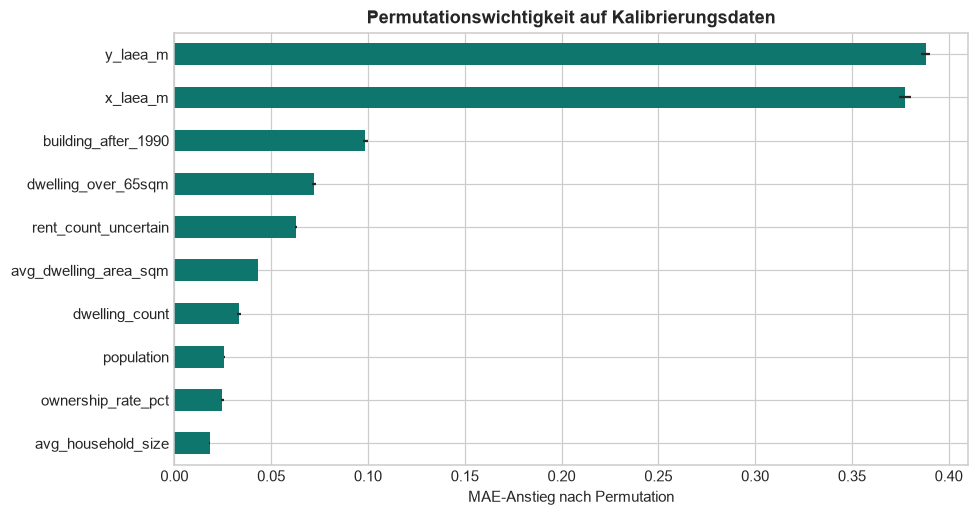

In [6]:
importance = pd.DataFrame(
    report["permutation_importance_on_calibration_sample"]["results"]
).sort_values("mae_increase_mean").tail(10)
ax = importance.plot.barh(x="feature", y="mae_increase_mean",
                          xerr="mae_increase_std", color=COLORS["teal"], legend=False)
ax.set(title="Permutationswichtigkeit auf Kalibrierungsdaten",
       xlabel="MAE-Anstieg nach Permutation", ylabel="")
plt.tight_layout(); plt.show()

## Finale Modellentscheidung und kritische Interpretation

- MAE 1,413 €/m² und R² 0,584 auf unbekannten Raumblöcken.
- 38,3 % MAE-Verbesserung gegenüber der fachlichen Baseline.
- Das nominelle 90%-Band erreicht nur 86,8 %: räumlicher Shift verletzt perfekte Austauschbarkeit. Die App zeigt daher empirisch ca. 87 % statt einer falschen 90%-Garantie.
- Neue Gebäude sind mit MAE 1,64–1,91 €/m² schwieriger; diese Grenze wird sichtbar.
- Wichtigkeit ist prädiktiv und nicht kausal.

## Go/No-Go und Übergabe an K

**Go mit sichtbaren Grenzen:** HGB erfüllt Daten-, Generalisierungs- und Nutzen-KPIs und gewinnt auch den dokumentierten Produktions-Trade-off. Die Unterdeckung des Intervalls und die schwächere Güte bei Neubauten verhindern keine Demonstrations-App, verlangen aber klare Warnungen.

An K werden `models/zensus_hgb.joblib`, Metadaten mit fester Feature-Reihenfolge, regionale Profile, GREIX-Zeitreihen und die gemessenen Qualitätskennzahlen übergeben. Das Testset bleibt nach dieser Entscheidung unverändert.

---

**Reproduzierbarkeit:** Die visualisierten Kennzahlen stammen aus versionierten JSON-/CSV-Artefakten. Die jeweils genannten Skripte erzeugen diese Artefakte aus den öffentlichen Rohdaten erneut. Relative Pfade funktionieren sowohl aus der Projektwurzel als auch aus `notebooks/`.